<img src="Logo_UNSAM.png" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº2
#### Santiago Boente

En este trabajo práctico tuvimos como finalidad simular el bloque de cuantización de un ADC de B bits en un rango de $\pm$VF Volts. Esta vez incluyendo la capacidad de muestrear a fs Hertz.

Para realizar esto, tomaremos como parámetros iniciales:
-Frecuencia  f0=fS/N=Δf
-Energía (o varianza) unitaria
-Frecuencia de muestreo fS=1000Hz
-Rango analógico de ±VF=2 Volts

Y para la secuencia de ruido:
-La señal que entra al ADC será sR = s + n. Siendo n la secuencia que simula la interferencia, y s la senoidal descrita anteriormente.
-La potencia del ruido será Pn = kn.Pq W siendo el factor k una escala para la potencia del ruido de cuantización.

-Pq = $\frac{q^2}{12}$

Finalmente usaremos para el primer experimento B = 4bits y kn = 1

In [4]:
import numpy as np
import matplotlib.pyplot as plt

"vmax: Amplitud maxima , dc: valor medio , ff: frecuencia, ph: fase en radianes , nn: numero de muestras , fs: frecuencia de muestreo" 

fs = 1000
N = 1000
A = np.sqrt(2)
vfs = 2 # Rango de tensión del ADC
B = 4   # Resolución del ADC [bits]
kn = 1  # Factor de escala del ruido analógico


def mi_funcion_sen(vmax, dc , ff , ph , nn , fs):
    
    ts = 1/fs
    tt = np.arange(0, nn, 1)*ts
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)

    return tt, xx 
"tt: vector de tiempo , xx: vector de señal"

tt, xx = mi_funcion_sen(A , 0 , fs/N , 0 , N , fs)


q = (vfs) / 2**B # Paso de cuantización
pq = (q**2)/12   # Potencia del ruido de cuantización
Pn = kn*pq       # Potencia del ruido analógico

snr_pn = 10 * np.log10(1/Pn) # SNR respecto al ruido analógico [dB]
ruido_pn = np.random.normal(0 , np.sqrt(Pn) , len(tt)) # Ruido analógico gaussiano de media 0 y desviación estándar sqrt(Pn)


Habiendo ya definido los parámetros iniciales, le añadiremos el ruido a la señal sinusoidal

In [5]:
#señal + ruido analógico (sR = s + n)
xxpn = xx + ruido_pn

Luego recordaremos el rango analógico del ADC al solicitado. Seguido de cuantizar la señal y finalmente calcularemos el error.

In [6]:
# recorte al rango del ADC
xxpn_clip = np.clip(xxpn, -vfs, vfs)

# cuantización
xxq = q * np.round(xxpn_clip / q)

#error
eq = xxq - xxpn_clip

Con todo esto hecho, graficaremos la amplitud de la señal en función del tiempo

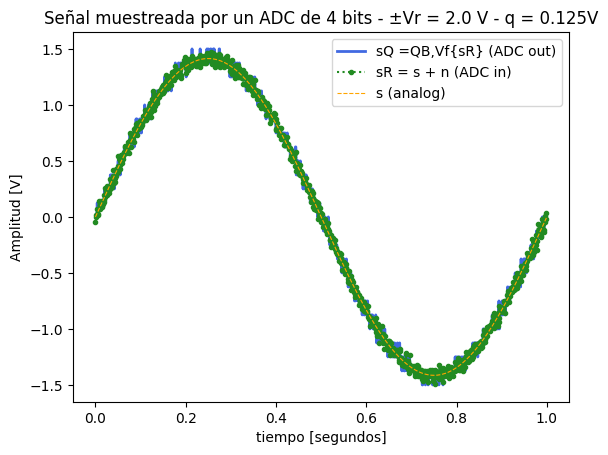

In [7]:
# GRÁFICO 1: Señal en el dominio del tiempo
plt.figure()
plt.plot(tt, xxq, color = 'royalblue',label='sQ =QB,Vf{sR} (ADC out)', linewidth = 2)
plt.plot(tt, xxpn, '.:', color = 'forestgreen',label = 'sR = s + n (ADC in)')
plt.plot(tt, xx, '--', color = 'orange', label = 's (analog)', linewidth = 0.8)
plt.title(f'Señal muestreada por un ADC de {B} bits - ±Vr = {vfs:.1f} V - q = {q:.3f}V')
plt.xlabel("tiempo [segundos]")
plt.ylabel("Amplitud [V]")
plt.legend()
plt.show()

Ahora definiremos el espectro de potencia, calculando la FFT de cada señal, normalizandola y posteriormente calculando la densidad de la frecuencia espectral .También generaremos un vector de frecuencias.

In [ ]:
# Espectro de potencia
XX = np.fft.fft(xx)/N
XX_mod = 2 * (np.abs(XX)**2)

XXPn = np.fft.fft(xxpn)/N
XXPn_mod = 2 * (np.abs(XXPn)**2)

XXQ = np.fft.fft(xxq)/N
XXQ_mod = 2 * (np.abs(XXQ)**2)

EQ = np.fft.fft(eq)/N
EQ_mod = 2 * (np.abs(EQ)**2)

# Vector de frecuencias
freq = np.fft.fftfreq(len(xx), 1/fs)

A continuación normalizaremos la magnitud a dB y calcularemos el piso teórico digital y analógico. 

In [ ]:
# magnitud normalizada en dB
XX_db = 10 * np.log10(XX_mod + 1e-12)
XXPn_db = 10 * np.log10(XXPn_mod + 1e-12)
XXQ_db = 10 * np.log10(XXQ_mod + 1e-12)
EQ_db = 10 * np.log10(EQ_mod + 1e-12)

piso_analog = 10 * np.log10(Pn/(N/2) + 1e-12)
print(f'Piso analógico: {piso_analog:.6f}')
piso_digital = 10 * np.log10(pq/(N/2) + 1e-12)
print(f'Piso digital: {piso_digital:.6f}')

Con todo esto podremos graficar la densidad de potencia espectral. Para esto limitaremos el rango del vector de frecuencias a N/2 